In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# ==========================================
# 1. SETUP & INDICES
# ==========================================
GEOS = ['Turin_City', 'Turin_Metro', 'Piedmont']
AGES = ['Young', 'Old']
WORKS = ['High_Exp', 'Mid_Exp', 'Low_Exp']

NUM_GROUPS = 18

def get_group_features(idx):
    """Returns (geo_idx, age_idx, work_idx) for a flat group index."""
    g = idx // 6
    rem = idx % 6
    a = rem // 3
    w = rem % 3
    return g, a, w

# ==========================================
# 2. PARAMETERS
# ==========================================
T_MAX = 1095        # 3 Years (Vaccine starts at day 365)
DT = 1.0

# Biology
SIGMA = 1/5.0      # Latency
EPSILON = 0.4      # Asymptomatic infectivity
XI = 1/120.0       # Natural immunity waning
XI_V = 1/365.0     # Vaccine immunity waning (lasts 1 years)
GAMMA_I = 1/10.0   
GAMMA_Q = 1/8.0
THETA_I = 0.15
THETA_A = 0.005  # Asymptomatic detection rate (with screening)

# Vaccination Parameters
VAX_START_DAY = 365
VAX_RATE_TOTAL = 4000.0  # Doses per day available for the whole population

# Lockdown parameters
LOCKDOWN_PERIODS = [
    # (365, 565)
]
LOCKDOWN_STRENGTH = 0.30  # Reduction factor during lockdown

# Build Heterogeneous Parameters (Same as before)
def build_parameters():
    beta = np.zeros((NUM_GROUPS, NUM_GROUPS))
    delta_I = np.zeros(NUM_GROUPS)
    delta_Q = np.zeros(NUM_GROUPS)
    # Different base transmission based on geography
    base_transmission = {0: 0.50,  # City
                         1: 0.05,  # Metro
                         2: 0.02}  # Piedmont

    for i in range(NUM_GROUPS):
        g_i, a_i, w_i = get_group_features(i)
        
        # Fatality Rates
        if a_i == 0: # Young
            delta_I[i], delta_Q[i] = 0.0002, 0.00005
        else:        # Old
            delta_I[i], delta_Q[i] = 0.005, 0.001

        for j in range(NUM_GROUPS):
            g_j, a_j, w_j = get_group_features(j)
            
            # 1. Geography factor (Mobility)
            # High contact if same region, low if different
            if g_i == g_j:
                f_geo = 1.0
            elif (g_i == 0 and g_j == 1) or (g_i == 1 and g_j == 0):
                f_geo = 0.20 # City-Metro limited connectivity
            else:
                f_geo = 0.05 # City-Piedmont or Metro-Piedmont minimal connectivity
            
            # 2. Age factor (Mixing)
            # Young people mix more than old people
            if a_i == 0 and a_j == 0: f_age = 1.2
            elif a_i == 1 and a_j == 1: f_age = 0.8
            else: f_age = 0.6
            
            # 3. Work factor (Exposure)
            # High exp (0) infects/gets infected more
            risk_map = {0: 2.5, 1: 0.8, 2: 0.2} # High, Mid, Low
            f_work = np.sqrt(risk_map[w_i] * risk_map[w_j])
            
            beta[i, j] = base_transmission[g_i] * f_geo * f_age * f_work

    return beta, delta_I, delta_Q

BETA, DELTA_I, DELTA_Q = build_parameters()

# ==========================================
# 3. STRATEGY LOGIC
# ==========================================

def get_vaccine_allocation(S_current, strategy_name, max_rate):
    """
    Allocates the global max_rate among groups based on S_current and strategy.
    Returns an array of rates v_k.
    """
    v_rates = np.zeros(NUM_GROUPS)
    remaining_capacity = max_rate
    
    # Define Priority Tiers based on strategy
    tiers = []
    
    if strategy_name == 'No_Vaccination':
        # No vaccination - return zeros
        return v_rates
    
    elif strategy_name == 'Old_First':
        # Tier 1: All Old groups; Tier 2: All Young groups
        t1 = [k for k in range(NUM_GROUPS) if get_group_features(k)[1] == 1]
        t2 = [k for k in range(NUM_GROUPS) if get_group_features(k)[1] == 0]
        tiers = [t1, t2]
        
    elif strategy_name == 'HighExp_First':
        # Tier 1: High Work; Tier 2: Mid; Tier 3: Low
        t1 = [k for k in range(NUM_GROUPS) if get_group_features(k)[2] == 0]
        t2 = [k for k in range(NUM_GROUPS) if get_group_features(k)[2] == 1]
        t3 = [k for k in range(NUM_GROUPS) if get_group_features(k)[2] == 2]
        tiers = [t1, t2, t3]
        
    elif strategy_name == 'Geographical':
        # Tier 1: City; Tier 2: Metro; Tier 3: Piedmont
        t1 = [k for k in range(NUM_GROUPS) if get_group_features(k)[0] == 0]
        t2 = [k for k in range(NUM_GROUPS) if get_group_features(k)[0] == 1]
        t3 = [k for k in range(NUM_GROUPS) if get_group_features(k)[0] == 2]
        tiers = [t1, t2, t3]
        
    else: # Default fallback
        tiers = [list(range(NUM_GROUPS))]

    # Distribute Capacity
    for tier_groups in tiers:
        if remaining_capacity <= 0:
            break
            
        # Total Susceptible in this tier
        tier_S_total = np.sum(S_current[tier_groups])
        
        if tier_S_total > 0:
            # Allocate as much capacity as possible to this tier
            # Either all remaining capacity OR all susceptibles in tier (whichever is smaller)
            capacity_for_tier = min(remaining_capacity, tier_S_total)
            
            # Distribute this capacity proportionally within the tier
            for k in tier_groups:
                if S_current[k] > 0:
                    share = S_current[k] / tier_S_total
                    v_rates[k] = share * capacity_for_tier
            
            # Subtract what we used from remaining capacity
            remaining_capacity -= capacity_for_tier
        # If tier has no susceptibles, continue to next tier
            
    return v_rates

# ==========================================
# 4. ODE SYSTEM (SAIQRS-V)
# ==========================================

def system_deriv(y, t, beta, delta_I, delta_Q, strategy):
    # Reshape: 7 cols -> S, A, I, Q, R, D, V
    state = y.reshape((NUM_GROUPS, 7))
    S, A, I, Q, R, D, V = state[:,0], state[:,1], state[:,2], state[:,3], state[:,4], state[:,5], state[:,6]
    
    # A. Determine Vaccination Rates
    v_rates = np.zeros(NUM_GROUPS)
    if t >= VAX_START_DAY:
        v_rates = get_vaccine_allocation(S, strategy, VAX_RATE_TOTAL)

        # Bound v_rates to prevent negative S (can't vaccinate more than exist)
        # Use a small time step approximation: v_rate * dt should not exceed S
        # For safety, cap at S / dt (assuming dt=1)
        # v_rates = np.minimum(v_rates, S * 0.1)  # Conservative: max 10% per day

    # B. Force of Infection with Lockdown
    # Government restrictions (time-dependent beta) - matching epidemic.ipynb
    current_beta = beta.copy()
    in_lockdown = any(start <= t < end for start, end in LOCKDOWN_PERIODS)
    if in_lockdown:
        current_beta = current_beta * LOCKDOWN_STRENGTH
        
    # Need to normalize by population size for proper per-capita rates
    # N = Living population (D is cumulative deaths, not in population)
    # V is in N because vaccinated people are still alive and part of population
    N = S + A + I + Q + R + V  # Total LIVING population in each group
    infectious_load = (I + EPSILON * A) / N # Prevalence (proportion infected)
    Lambda = current_beta.dot(infectious_load)
    
    # C. Derivatives
    dS = -S * Lambda + XI * R + XI_V * V - v_rates
    dA = S * Lambda - (SIGMA + THETA_A) * A  # Asymptomatic progress to symptomatic or detected
    dI = SIGMA * A - (THETA_I + GAMMA_I + delta_I) * I
    dQ = THETA_I * I + THETA_A * A - (GAMMA_Q + delta_Q) * Q  # Only I and A go to Q
    dR = GAMMA_I * I + GAMMA_Q * Q - XI * R  # Only symptomatic/quarantined recover
    dD = delta_I * I + delta_Q * Q
    dV = v_rates - XI_V * V
    
    return np.stack([dS, dA, dI, dQ, dR, dD, dV], axis=1).flatten()

# ==========================================
# 5. RUNNER
# ==========================================
def init_populations():
    """
    Initializes the populations for each group.
    Returns a flat array of size 108 (7 compartments * 18 groups).
    """
    y0 = np.zeros((NUM_GROUPS, 7))

    populations = {
        'Turin_City': { 'Young': 630000, 'Old': 270000 },
        'Turin_Metro': { 'Young': 1040000, 'Old': 360000 },
        'Piedmont': { 'Young': 1400000, 'Old': 500000 },
    }

    exposure_distribution = {
        'High_Exp': 0.15,
        'Mid_Exp': 0.5,
        'Low_Exp': 0.35,
    }

    # Seed only in Turin City (most connected) with fewer initial cases
    for idx in range(NUM_GROUPS):
        g_idx, a_idx, w_idx = get_group_features(idx)
        g = GEOS[g_idx]
        a = AGES[a_idx]
        w = WORKS[w_idx]
        pop_size = populations[g][a] * exposure_distribution[w]
        
        # Start with minimal seed: 50 infections total in one group
        if g_idx == 0 and a_idx == 0 and w_idx == 0:  # Only Turin City, Young, High Exposure
            y0[idx, 0] = pop_size - 10.0
            y0[idx, 1] = 10.0  # 10 initial seeds in single group
        else:
            y0[idx, 0] = pop_size  # Everyone else susceptible
            y0[idx, 1] = 0.0       # No initial infections
        
    return y0.flatten()

def run_strategy_comparison():
    # Setup Initial State
    y0_flat = init_populations()
    
    t = np.linspace(0, T_MAX, int(T_MAX/DT)+1)
    
    strategies = ['No_Vaccination', 'Old_First', 'HighExp_First', 'Geographical', 'Uniform']
    results = {}
    
    print(f"Simulating {len(strategies)} strategies...")
    
    for strat in strategies:
        print(f"Running {strat}...")
        # Note: 'args' must match function signature
        ret = odeint(system_deriv, y0_flat, t, args=(BETA, DELTA_I, DELTA_Q, strat))
        results[strat] = ret

    return t, results

Simulating 5 strategies...
Running No_Vaccination...
Running Old_First...
Running HighExp_First...
Running Geographical...
Running Uniform...

VACCINATION STRATEGIES - 2x2 DASHBOARD


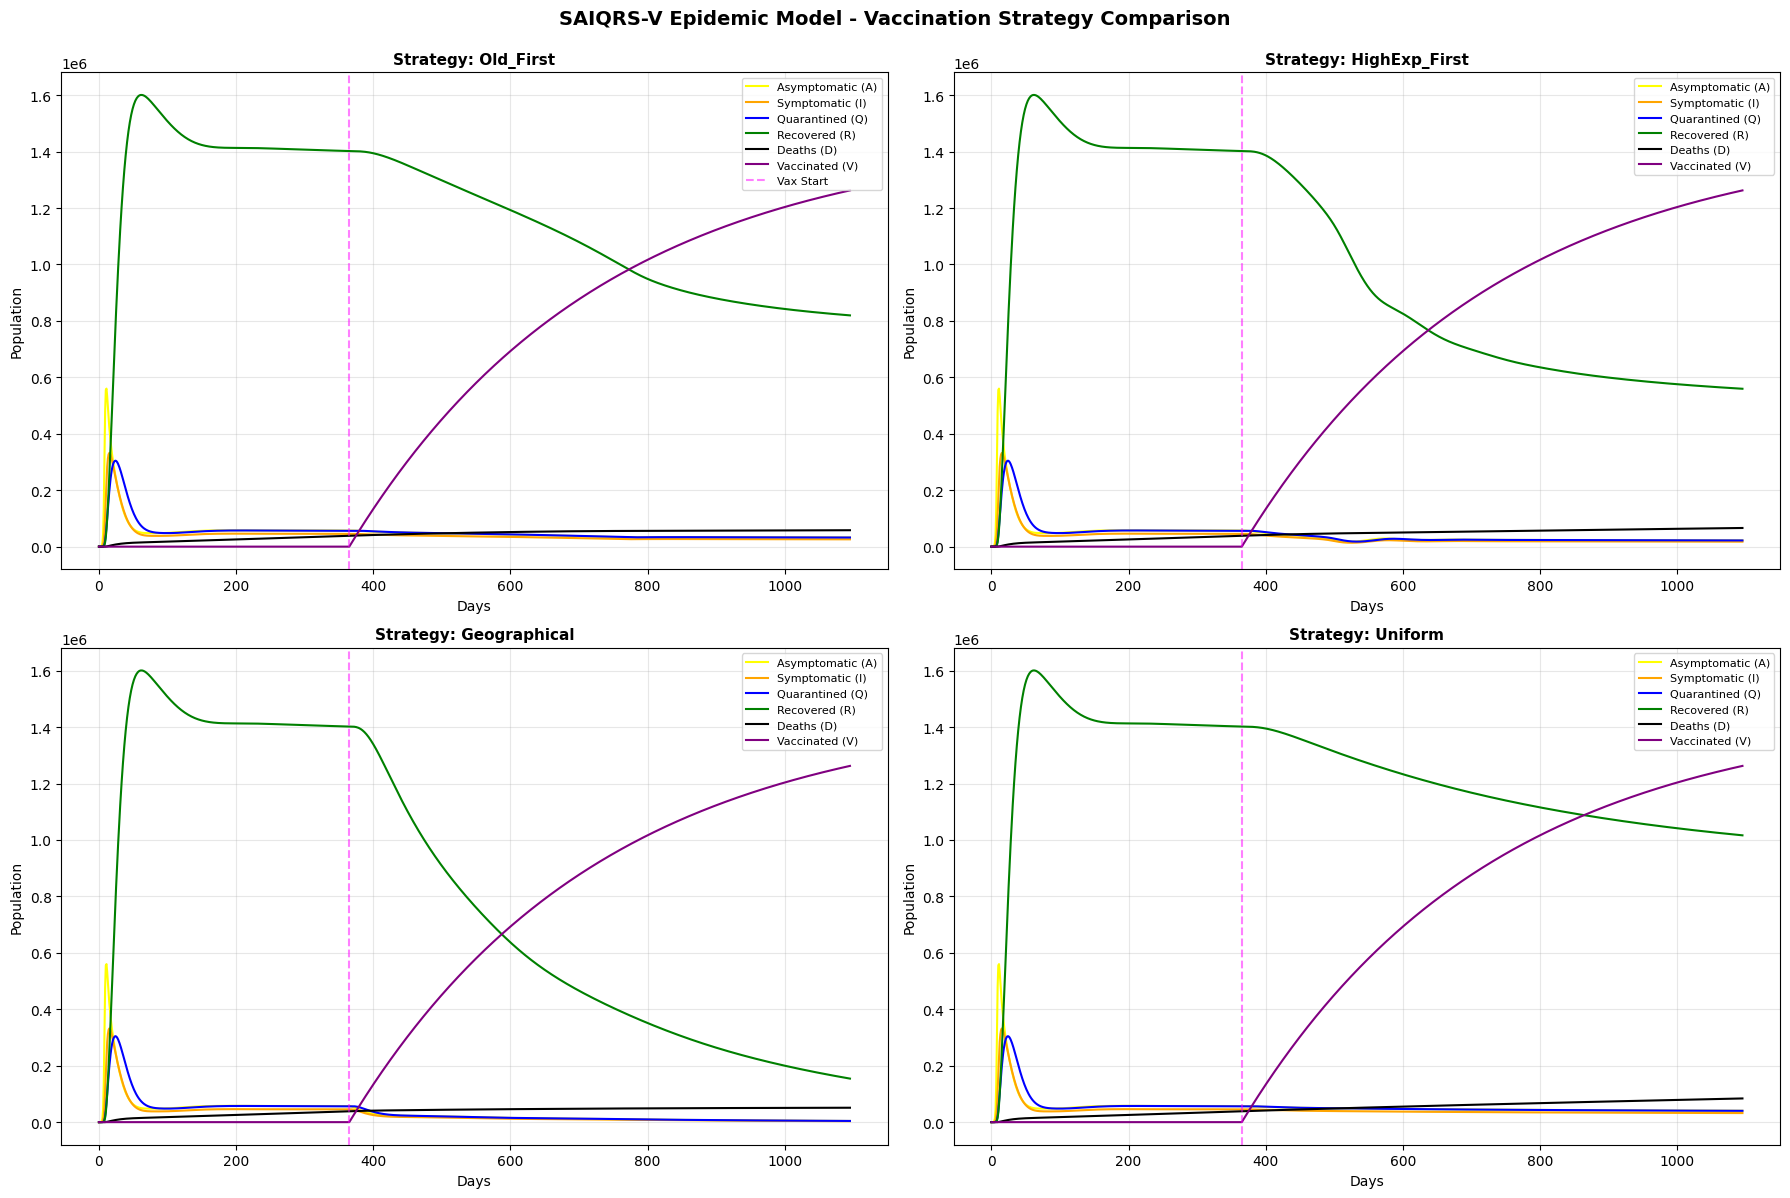


=== Epidemic Summary for All Strategies ===

Old_First:
  Total Population: 4200000
  Peak Symptomatic: 331758 on day 15
  Peak Asymptomatic: 560088 on day 11
  Total Deaths: 58175
  Final Recovered: 819543
  Final Vaccinated: 1262410
  Attack Rate: 20.90%
  Deaths per 100k: 1385.1

HighExp_First:
  Total Population: 4200000
  Peak Symptomatic: 331758 on day 15
  Peak Asymptomatic: 560088 on day 11
  Total Deaths: 66105
  Final Recovered: 559491
  Final Vaccinated: 1262410
  Attack Rate: 14.90%
  Deaths per 100k: 1573.9

Geographical:
  Total Population: 4200000
  Peak Symptomatic: 331758 on day 15
  Peak Asymptomatic: 560088 on day 11
  Total Deaths: 51040
  Final Recovered: 154305
  Final Vaccinated: 1262410
  Attack Rate: 4.89%
  Deaths per 100k: 1215.2

Uniform:
  Total Population: 4200000
  Peak Symptomatic: 331758 on day 15
  Peak Asymptomatic: 560088 on day 11
  Total Deaths: 83946
  Final Recovered: 1016406
  Final Vaccinated: 1262410
  Attack Rate: 26.20%
  Deaths per 100k: 1

<Figure size 1400x500 with 0 Axes>

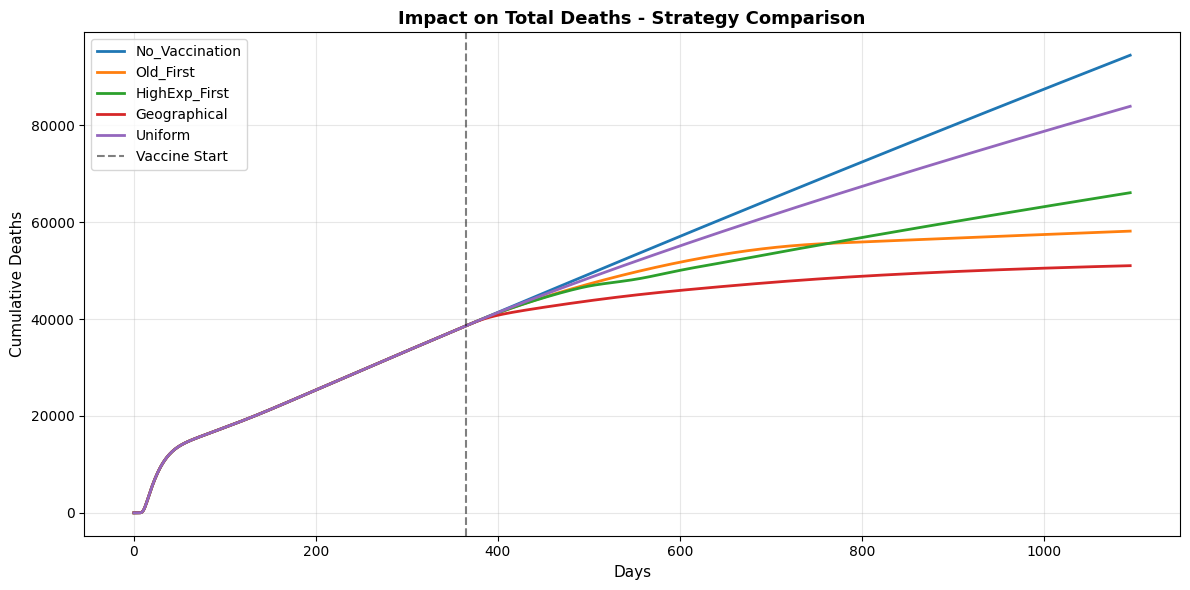


=== STRATEGY COMPARISON SUMMARY ===

No_Vaccination:
  Final Deaths: 94499
  Deaths per 100k: 2250.0
  Susceptible at day 365 (vaccine start): 2600067
  Final Vaccinated: 0 (0.0%)
  Final Recovered: 1368211 (32.6%)
  Total Immune (V+R): 32.6%

Old_First:
  Final Deaths: 58175
  Deaths per 100k: 1385.1
  Susceptible at day 365 (vaccine start): 2600067
  Final Vaccinated: 1262410 (30.1%)
  Final Recovered: 819543 (19.5%)
  Total Immune (V+R): 49.6%

HighExp_First:
  Final Deaths: 66105
  Deaths per 100k: 1573.9
  Susceptible at day 365 (vaccine start): 2600067
  Final Vaccinated: 1262410 (30.1%)
  Final Recovered: 559491 (13.3%)
  Total Immune (V+R): 43.4%

Geographical:
  Final Deaths: 51040
  Deaths per 100k: 1215.2
  Susceptible at day 365 (vaccine start): 2600067
  Final Vaccinated: 1262410 (30.1%)
  Final Recovered: 154305 (3.7%)
  Total Immune (V+R): 33.7%

Uniform:
  Final Deaths: 83946
  Deaths per 100k: 1998.7
  Susceptible at day 365 (vaccine start): 2600067
  Final Vaccinated

<Figure size 640x480 with 0 Axes>

In [21]:
# ==========================================
# 6. PLOTTING
# ==========================================

def plot_all_strategies_dashboard(t, res_dict):
    """
    Create a 2x2 dashboard showing all vaccination strategies together.
    """
    strategies = list(res_dict.keys())
    n_strategies = len(strategies)
    
    # Create 2x2 subplot grid
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    axes = axes.flatten()
    
    for idx, strat in enumerate(strategies[:4]):  # Limit to 4 strategies for 2x2 grid
        data = res_dict[strat]
        ax = axes[idx]
        
        # Reshape data
        data_rs = data.reshape((len(t), NUM_GROUPS, 7))
        
        # Aggregate across all groups
        total_A = np.sum(data_rs[:, :, 1], axis=1)  # Asymptomatic
        total_I = np.sum(data_rs[:, :, 2], axis=1)  # Symptomatic
        total_Q = np.sum(data_rs[:, :, 3], axis=1)  # Quarantined
        total_R = np.sum(data_rs[:, :, 4], axis=1)  # Recovered
        total_D = np.sum(data_rs[:, :, 5], axis=1)  # Deaths
        total_V = np.sum(data_rs[:, :, 6], axis=1)  # Vaccinated
        
        # Plot on subplot
        ax.plot(t, total_A, label='Asymptomatic (A)', color='yellow', linewidth=1.5)
        ax.plot(t, total_I, label='Symptomatic (I)', color='orange', linewidth=1.5)
        ax.plot(t, total_Q, label='Quarantined (Q)', color='blue', linewidth=1.5)
        ax.plot(t, total_R, label='Recovered (R)', color='green', linewidth=1.5)
        ax.plot(t, total_D, label='Deaths (D)', color='black', linewidth=1.5)
        ax.plot(t, total_V, label='Vaccinated (V)', color='purple', linewidth=1.5)
        
        # Mark lockdown periods
        for i, (start, end) in enumerate(LOCKDOWN_PERIODS, 1):
            label_start = 'Lockdown Start' if i == 1 and idx == 0 else None
            label_end = 'Lockdown End' if i == 1 and idx == 0 else None
            ax.axvline(x=start, linestyle='--', color='red', linewidth=1.5, alpha=0.5, label=label_start)
            ax.axvline(x=end, linestyle='--', color='darkgreen', linewidth=1.5, alpha=0.5, label=label_end)
        
        # Mark vaccination start
        ax.axvline(x=VAX_START_DAY, linestyle='--', color='magenta', linewidth=1.5, alpha=0.5, 
                  label='Vax Start' if idx == 0 else None)
        
        ax.set_title(f'Strategy: {strat}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Days', fontsize=10)
        ax.set_ylabel('Population', fontsize=10)
        ax.legend(loc='best', fontsize=8)
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots if fewer than 4 strategies
    for i in range(n_strategies, 4):
        axes[i].axis('off')
    
    plt.suptitle('SAIQRS-V Epidemic Model - Vaccination Strategy Comparison', 
                 fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig('vaccination_strategies_dashboard.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print summary statistics for all strategies
    print("\n=== Epidemic Summary for All Strategies ===")
    for strat, data in res_dict.items():
        data_rs = data.reshape((len(t), NUM_GROUPS, 7))
        total_S = np.sum(data_rs[:, :, 0], axis=1)
        total_A = np.sum(data_rs[:, :, 1], axis=1)
        total_I = np.sum(data_rs[:, :, 2], axis=1)
        total_R = np.sum(data_rs[:, :, 4], axis=1)
        total_D = np.sum(data_rs[:, :, 5], axis=1)
        total_V = np.sum(data_rs[:, :, 6], axis=1)
        
        print(f"\n{strat}:")
        print(f"  Total Population: {total_S[0] + total_A[0]:.0f}")
        print(f"  Peak Symptomatic: {np.max(total_I):.0f} on day {np.argmax(total_I)}")
        print(f"  Peak Asymptomatic: {np.max(total_A):.0f} on day {np.argmax(total_A)}")
        print(f"  Total Deaths: {total_D[-1]:.0f}")
        print(f"  Final Recovered: {total_R[-1]:.0f}")
        print(f"  Final Vaccinated: {total_V[-1]:.0f}")
        print(f"  Attack Rate: {(total_R[-1] + total_D[-1]) / (total_S[0] + total_A[0]) * 100:.2f}%")
        print(f"  Deaths per 100k: {total_D[-1] / (total_S[0] + total_A[0]) * 100000:.1f}")


if __name__ == "__main__":
    t, res_dict = run_strategy_comparison()

    res_dict_vax = {}
    for strat, data in res_dict.items():
        if strat != 'No_Vaccination':
            res_dict_vax[strat] = data
    
    # Plot all strategies in a 2x2 dashboard
    print("\n" + "="*70)
    print("VACCINATION STRATEGIES - 2x2 DASHBOARD")
    print("="*70)
    
    plot_all_strategies_dashboard(t, res_dict_vax)
    
    # Also create comparison plot
    print("\n" + "="*70)
    print("COMPARATIVE ANALYSIS ACROSS STRATEGIES")
    print("="*70)
    
    plt.figure(figsize=(14, 5))
    plt.figure(figsize=(12, 6))
    # Plot 1: Total Deaths Comparison
    # Total Deaths Comparison
    for strat, data in res_dict.items():
        data_rs = data.reshape((len(t), NUM_GROUPS, 7))
        total_deaths = np.sum(data_rs[:, :, 5], axis=1) # Col 5 is D
        plt.plot(t, total_deaths, label=strat, linewidth=2)
        
    plt.axvline(x=VAX_START_DAY, linestyle='--', color='k', alpha=0.5, label='Vaccine Start')
    plt.title("Impact on Total Deaths - Strategy Comparison", fontsize=13, fontweight='bold')
    plt.xlabel("Days", fontsize=11)
    plt.ylabel("Cumulative Deaths", fontsize=11)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('strategy_comparison_total_deaths.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print comparative statistics
    print(f"\n=== STRATEGY COMPARISON SUMMARY ===")
    for strat, data in res_dict.items():
        data_rs = data.reshape((len(t), NUM_GROUPS, 7))
        total_deaths = np.sum(data_rs[:, :, 5], axis=1)
        total_S_initial = np.sum(data_rs[0, :, 0])
        total_A_initial = np.sum(data_rs[0, :, 1])
        initial_pop = total_S_initial + total_A_initial
        # Additional metrics
        vax_start_idx = VAX_START_DAY  # Day 365
        susceptible_at_vax_start = np.sum(data_rs[vax_start_idx, :, 0])
        total_vaccinated_end = np.sum(data_rs[-1, :, 6])
        total_recovered_end = np.sum(data_rs[-1, :, 4])
        
        print(f"\n{strat}:")
        print(f"  Final Deaths: {total_deaths[-1]:.0f}")
        print(f"  Deaths per 100k: {total_deaths[-1]/initial_pop*100000:.1f}")
        print(f"  Susceptible at day {VAX_START_DAY} (vaccine start): {susceptible_at_vax_start:.0f}")
        print(f"  Final Vaccinated: {total_vaccinated_end:.0f} ({total_vaccinated_end/initial_pop*100:.1f}%)")
        print(f"  Final Recovered: {total_recovered_end:.0f} ({total_recovered_end/initial_pop*100:.1f}%)")
        print(f"  Total Immune (V+R): {(total_vaccinated_end+total_recovered_end)/initial_pop*100:.1f}%")
    plt.tight_layout()
    # Create comparison tables
    print("\n" + "="*70)
    print("COMPARISON TABLES")
    print("="*70)
    
    # Table 1: Deaths and Attack Rate
    print("\n--- Table 1: Mortality and Attack Rate ---")
    print(f"{'Strategy':<20} {'Deaths':<12} {'Deaths/100k':<15} {'Attack Rate %':<15}")
    print("-" * 62)
    
    for strat, data in res_dict.items():
        data_rs = data.reshape((len(t), NUM_GROUPS, 7))
        total_deaths = np.sum(data_rs[:, :, 5], axis=1)
        total_S_initial = np.sum(data_rs[0, :, 0])
        total_A_initial = np.sum(data_rs[0, :, 1])
        initial_pop = total_S_initial + total_A_initial
        
        final_deaths = total_deaths[-1]
        deaths_per_100k = final_deaths / initial_pop * 100000
        
        total_recovered_end = np.sum(data_rs[-1, :, 4])
        attack_rate = (total_recovered_end + final_deaths) / initial_pop * 100
        
        print(f"{strat:<20} {final_deaths:>11.0f} {deaths_per_100k:>14.1f} {attack_rate:>14.2f}")
    
    # Table 2: Vaccination Coverage and Immunity
    print("\n--- Table 2: Vaccination Coverage and Final Immunity ---")
    print(f"{'Strategy':<20} {'Final Vax %':<15} {'Final Rec %':<15} {'Total Immune %':<15}")
    print("-" * 65)
    
    for strat, data in res_dict.items():
        data_rs = data.reshape((len(t), NUM_GROUPS, 7))
        total_S_initial = np.sum(data_rs[0, :, 0])
        total_A_initial = np.sum(data_rs[0, :, 1])
        initial_pop = total_S_initial + total_A_initial
        
        total_vaccinated_end = np.sum(data_rs[-1, :, 6])
        total_recovered_end = np.sum(data_rs[-1, :, 4])
        
        vax_pct = total_vaccinated_end / initial_pop * 100
        rec_pct = total_recovered_end / initial_pop * 100
        immune_pct = (total_vaccinated_end + total_recovered_end) / initial_pop * 100
        final_deaths = total_deaths[-1]
        print(f"{strat:<20} {vax_pct:>14.2f} {rec_pct:>14.2f} {immune_pct:>14.2f}")
    
    # Table 3: Peak Infections
    print("\n--- Table 3: Peak Infections ---")
    print(f"{'Strategy':<20} {'Peak Symp (I)':<18} {'Day':<8} {'Peak Asymp (A)':<18} {'Day':<8}")
    print("-" * 72)
    
    for strat, data in res_dict.items():
        data_rs = data.reshape((len(t), NUM_GROUPS, 7))
        total_I = np.sum(data_rs[:, :, 2], axis=1)
        total_A = np.sum(data_rs[:, :, 1], axis=1)
        
        peak_I = np.max(total_I)
        day_peak_I = np.argmax(total_I)
        peak_A = np.max(total_A)
        day_peak_A = np.argmax(total_A)
        
        print(f"{strat:<20} {peak_I:>17.0f} {day_peak_I:>7} {peak_A:>17.0f} {day_peak_A:>7}")
    
    # Table 4: Relative Improvement vs No Vaccination
    print("\n--- Table 4: Relative Improvement vs No Vaccination Baseline ---")
    print(f"{'Strategy':<20} {'Deaths Reduced':<18} {'Attack Rate Reduced':<22}")
    print("-" * 60)
    
    # Get baseline (No_Vaccination) values
    if 'No_Vaccination' in res_dict:
        baseline_data = res_dict['No_Vaccination'].reshape((len(t), NUM_GROUPS, 7))
        baseline_deaths = np.sum(baseline_data[:, :, 5], axis=1)[-1]
        baseline_S_initial = np.sum(baseline_data[0, :, 0])
        baseline_A_initial = np.sum(baseline_data[0, :, 1])
        baseline_pop = baseline_S_initial + baseline_A_initial
        baseline_recovered = np.sum(baseline_data[-1, :, 4])
        baseline_attack_rate = (baseline_recovered + baseline_deaths) / baseline_pop * 100
        
        for strat, data in res_dict.items():
            if strat == 'No_Vaccination':
                print(f"{strat:<20} {'(Baseline)':>17} {'(Baseline)':>21}")
            else:
                data_rs = data.reshape((len(t), NUM_GROUPS, 7))
                total_deaths = np.sum(data_rs[:, :, 5], axis=1)[-1]
                total_S_initial = np.sum(data_rs[0, :, 0])
                total_A_initial = np.sum(data_rs[0, :, 1])
                initial_pop = total_S_initial + total_A_initial
                total_recovered = np.sum(data_rs[-1, :, 4])
                attack_rate = (total_recovered + total_deaths) / initial_pop * 100
                
                deaths_reduced = (1 - total_deaths / baseline_deaths) * 100
                attack_reduced = (1 - attack_rate / baseline_attack_rate) * 100
                
                print(f"{strat:<20} {deaths_reduced:>16.1f}% {attack_reduced:>20.1f}%")


DETAILED GROUP ANALYSIS


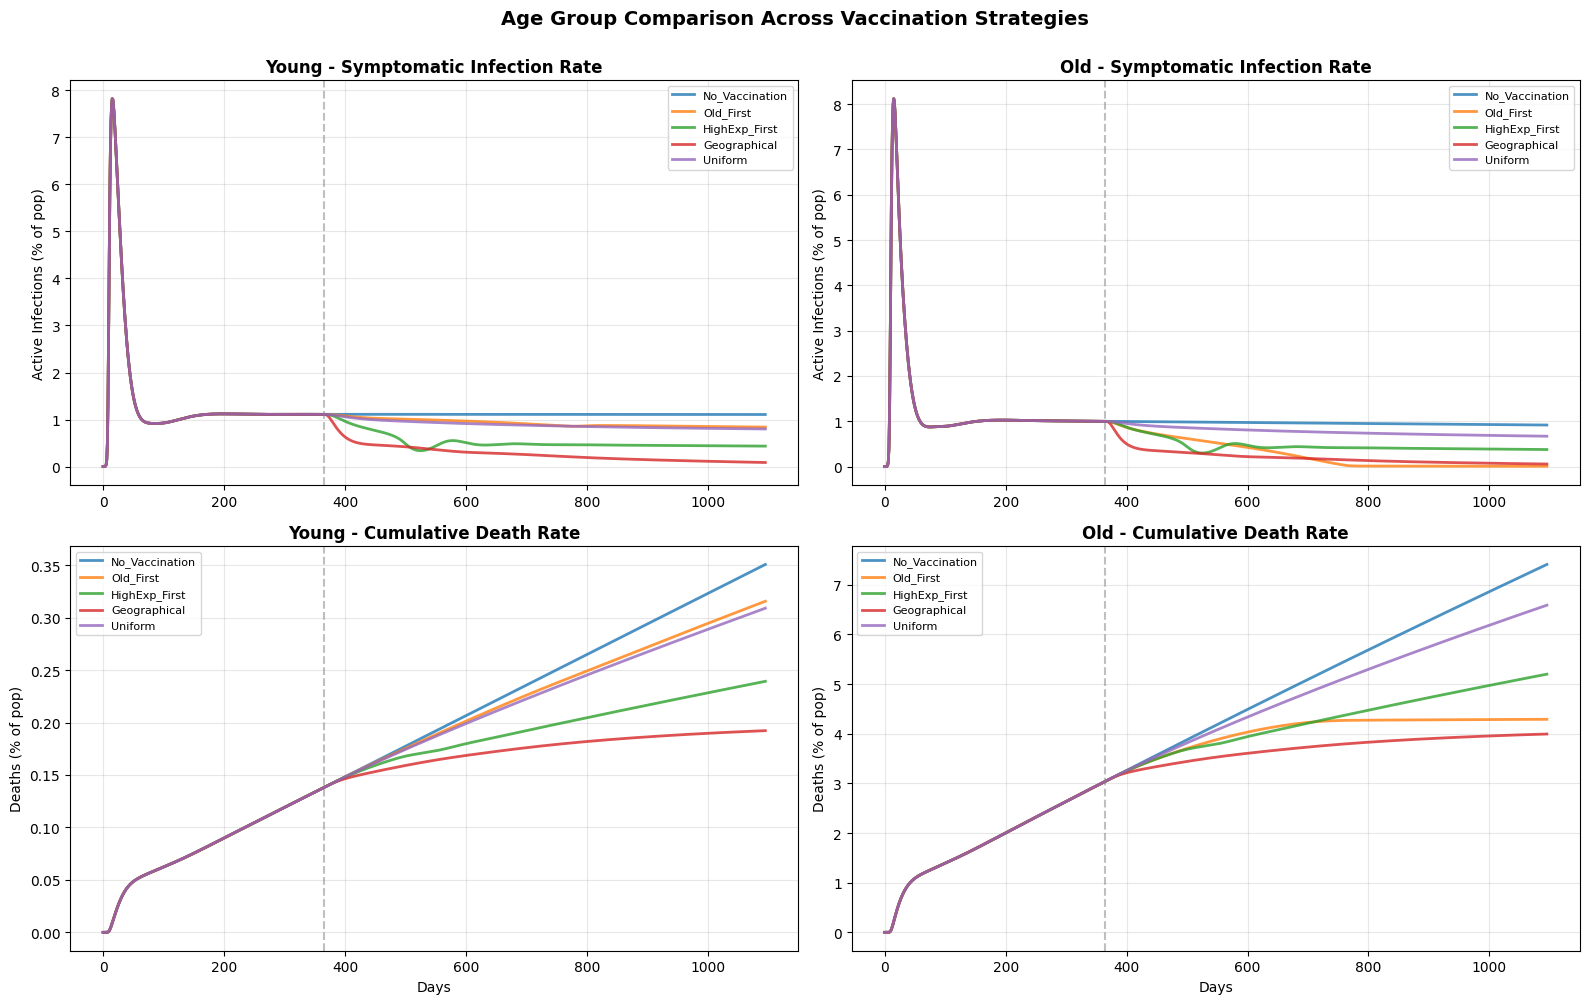

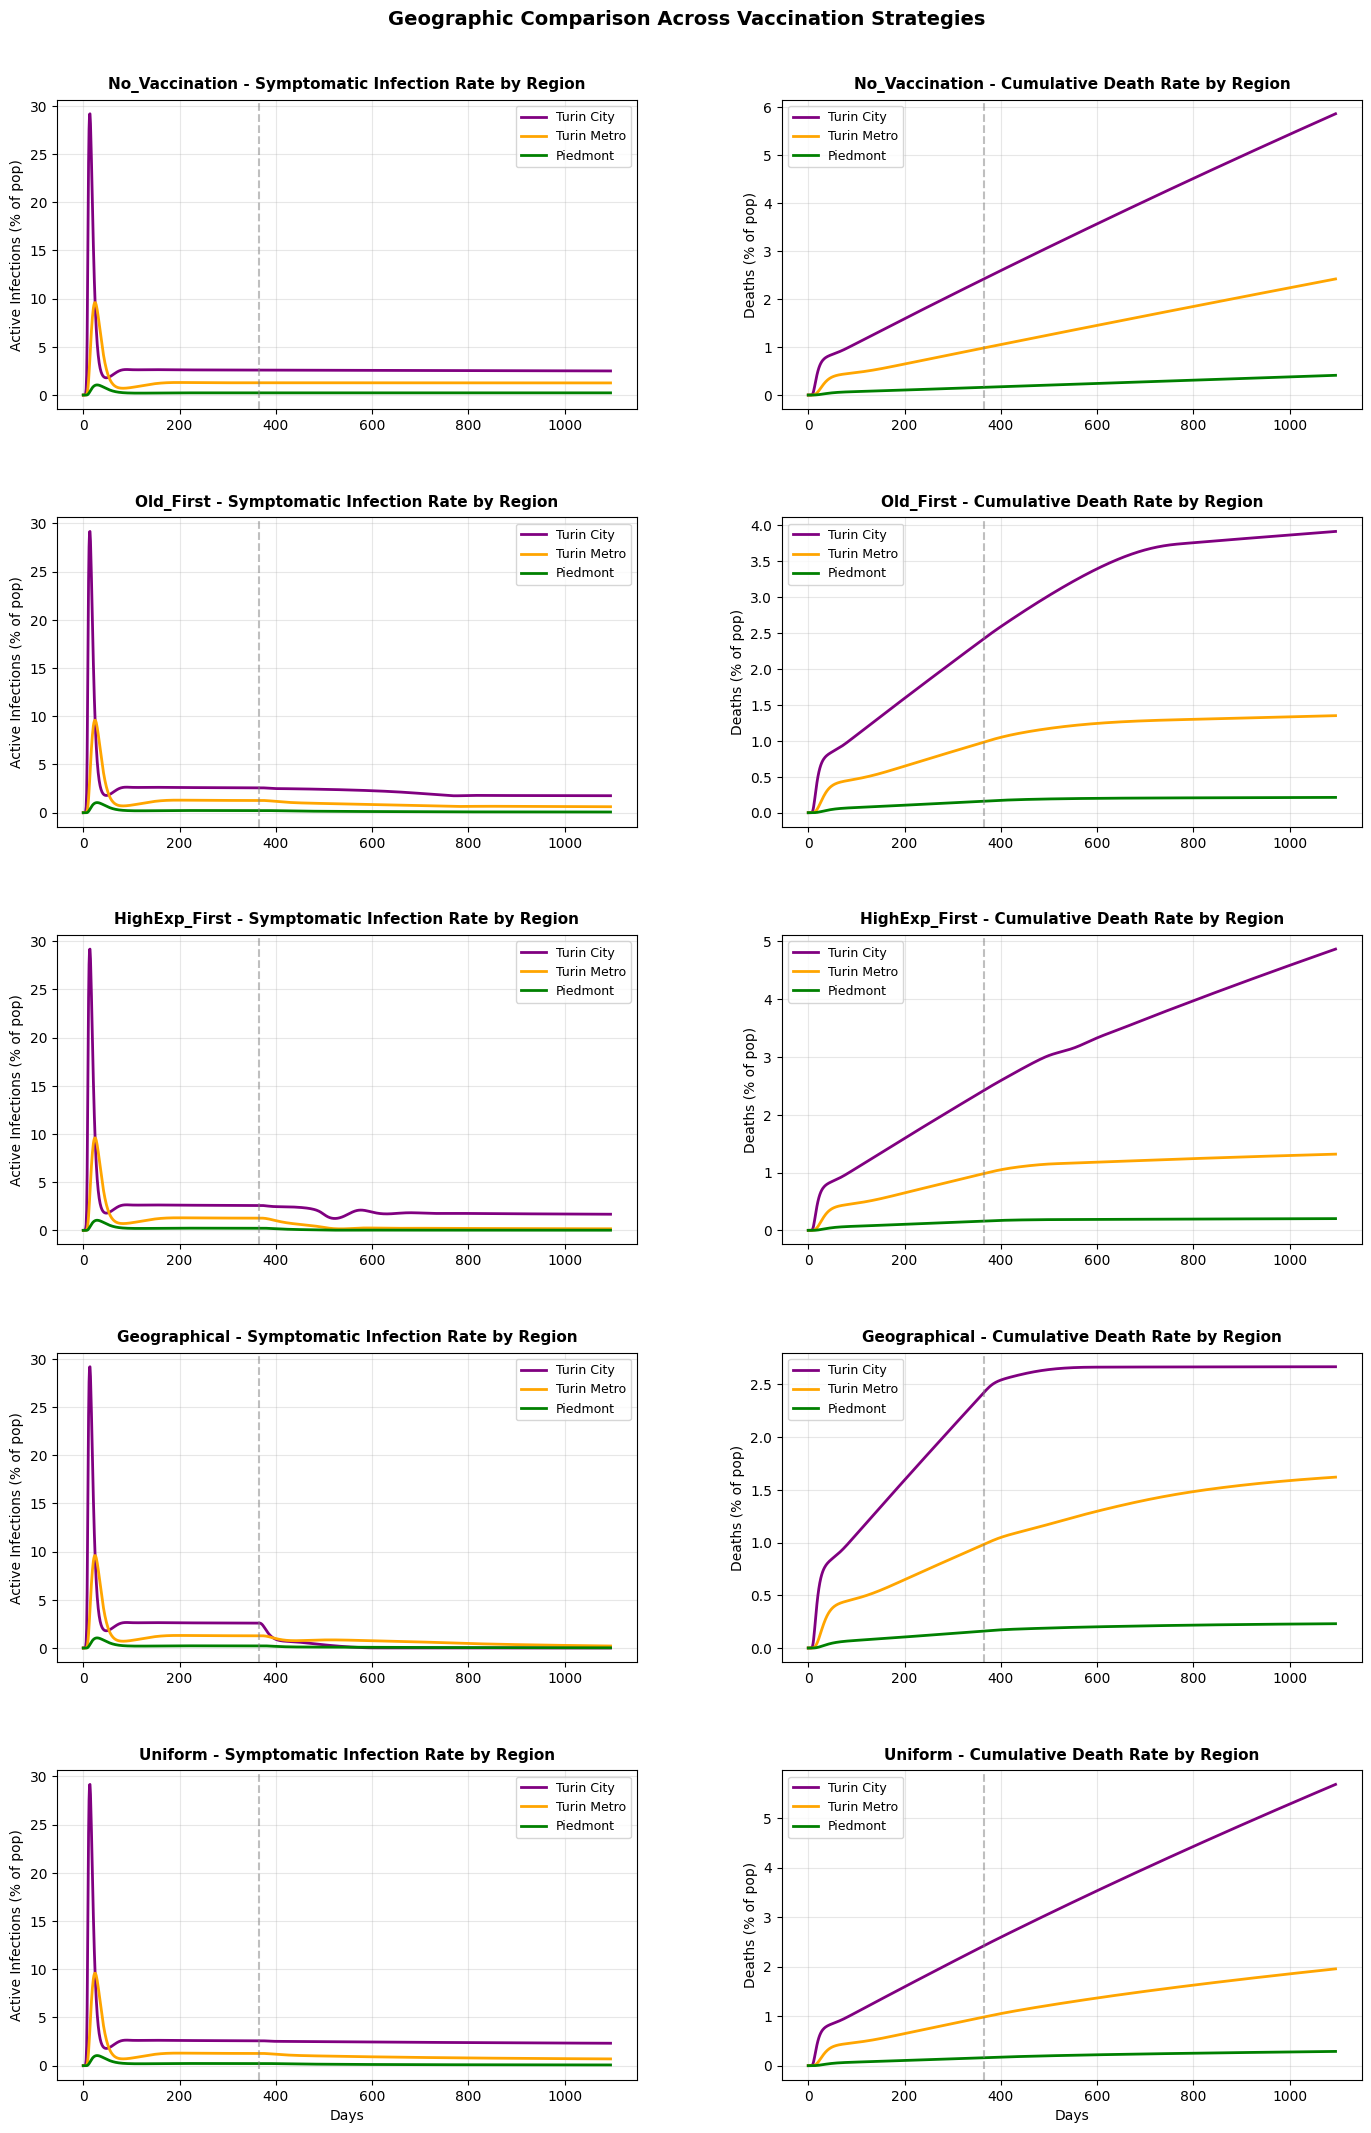

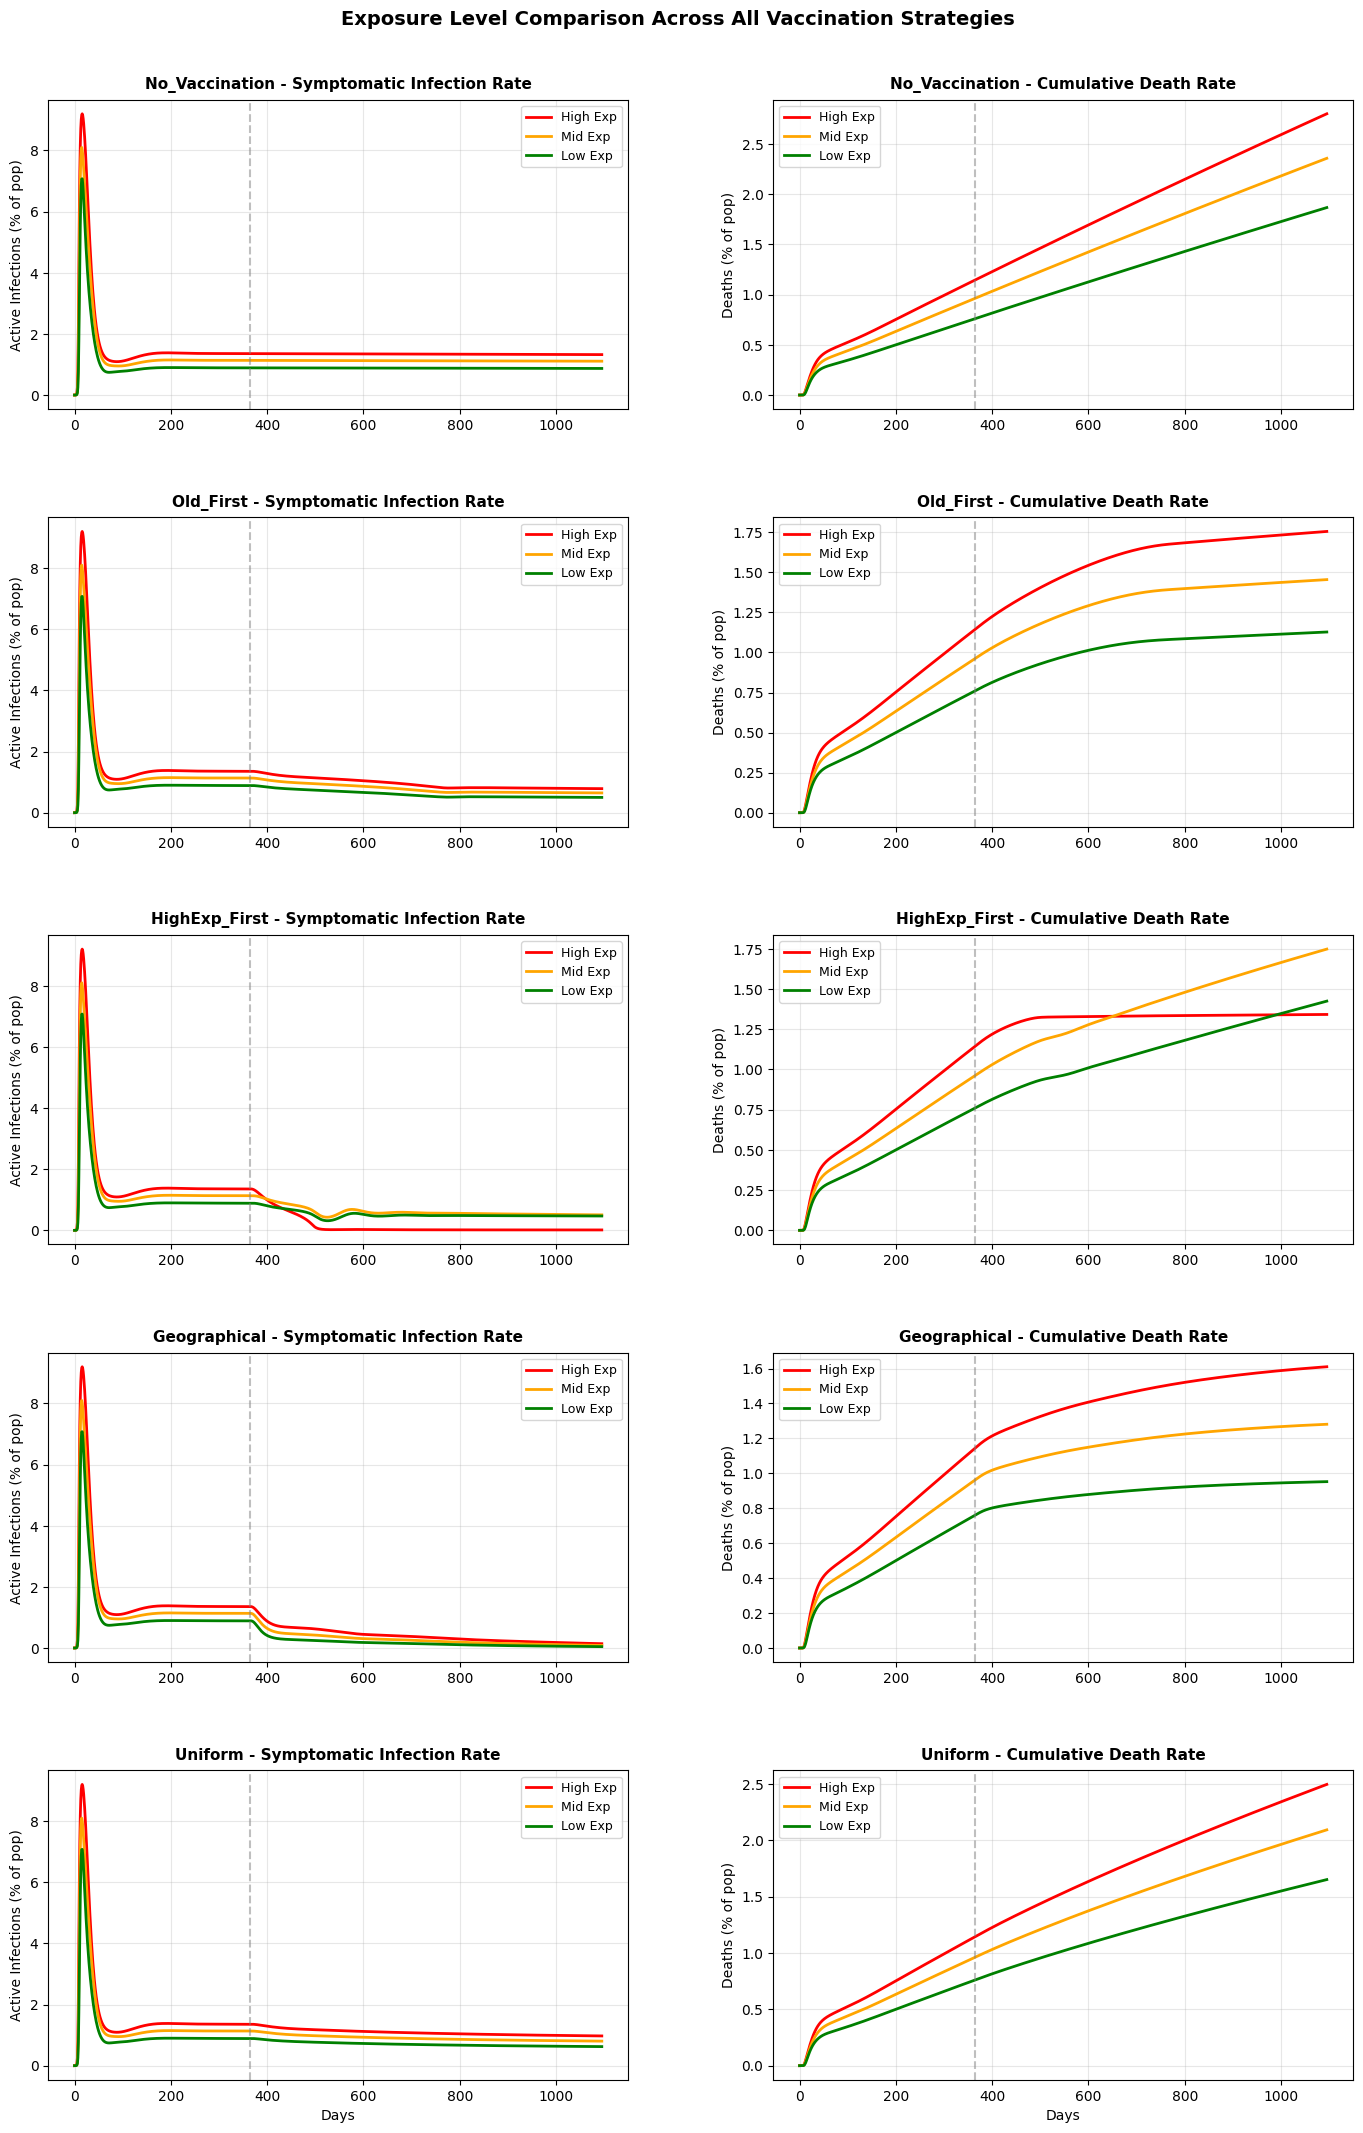

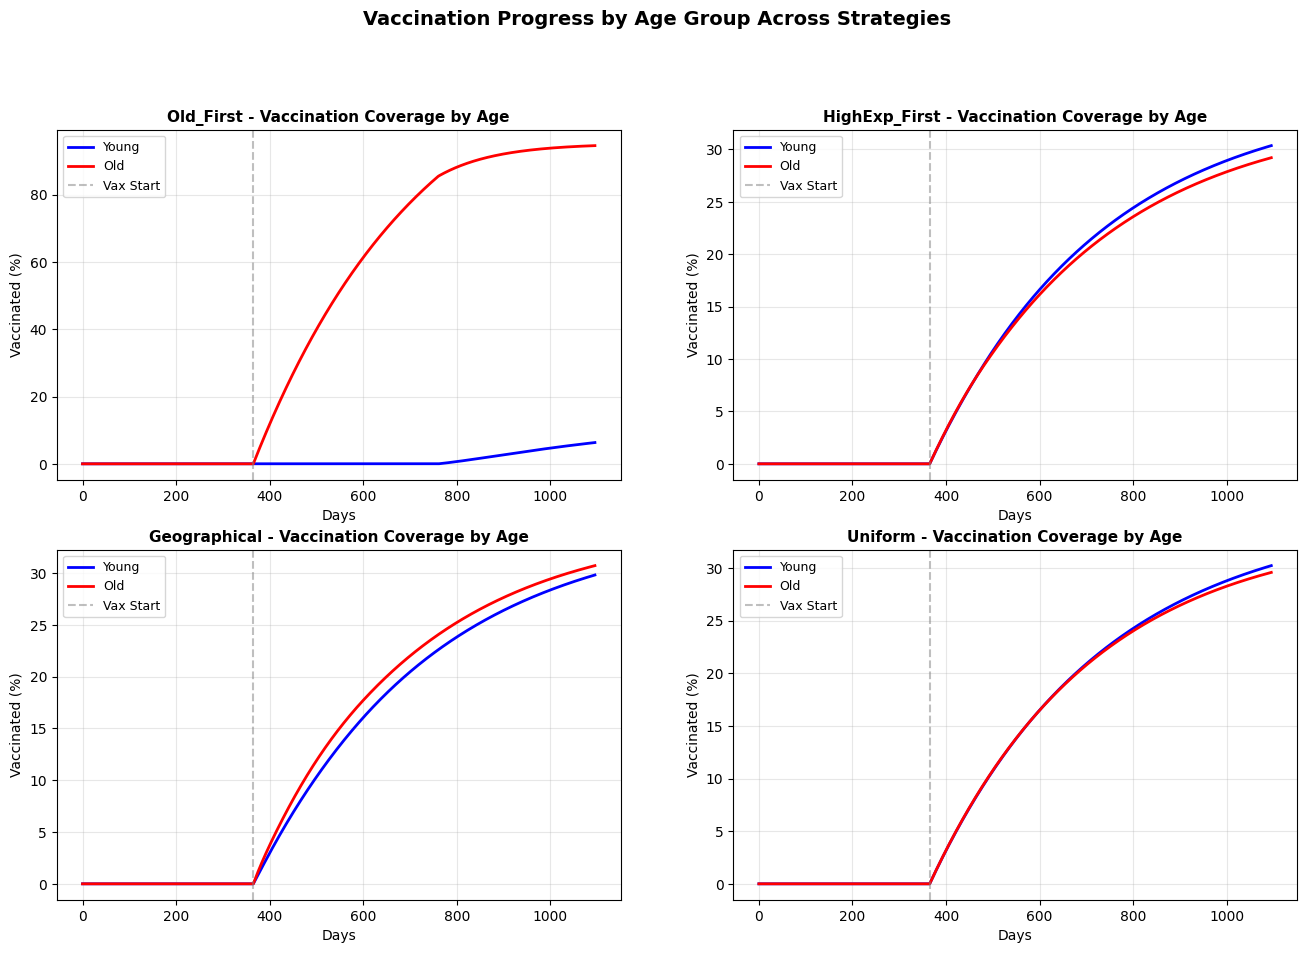

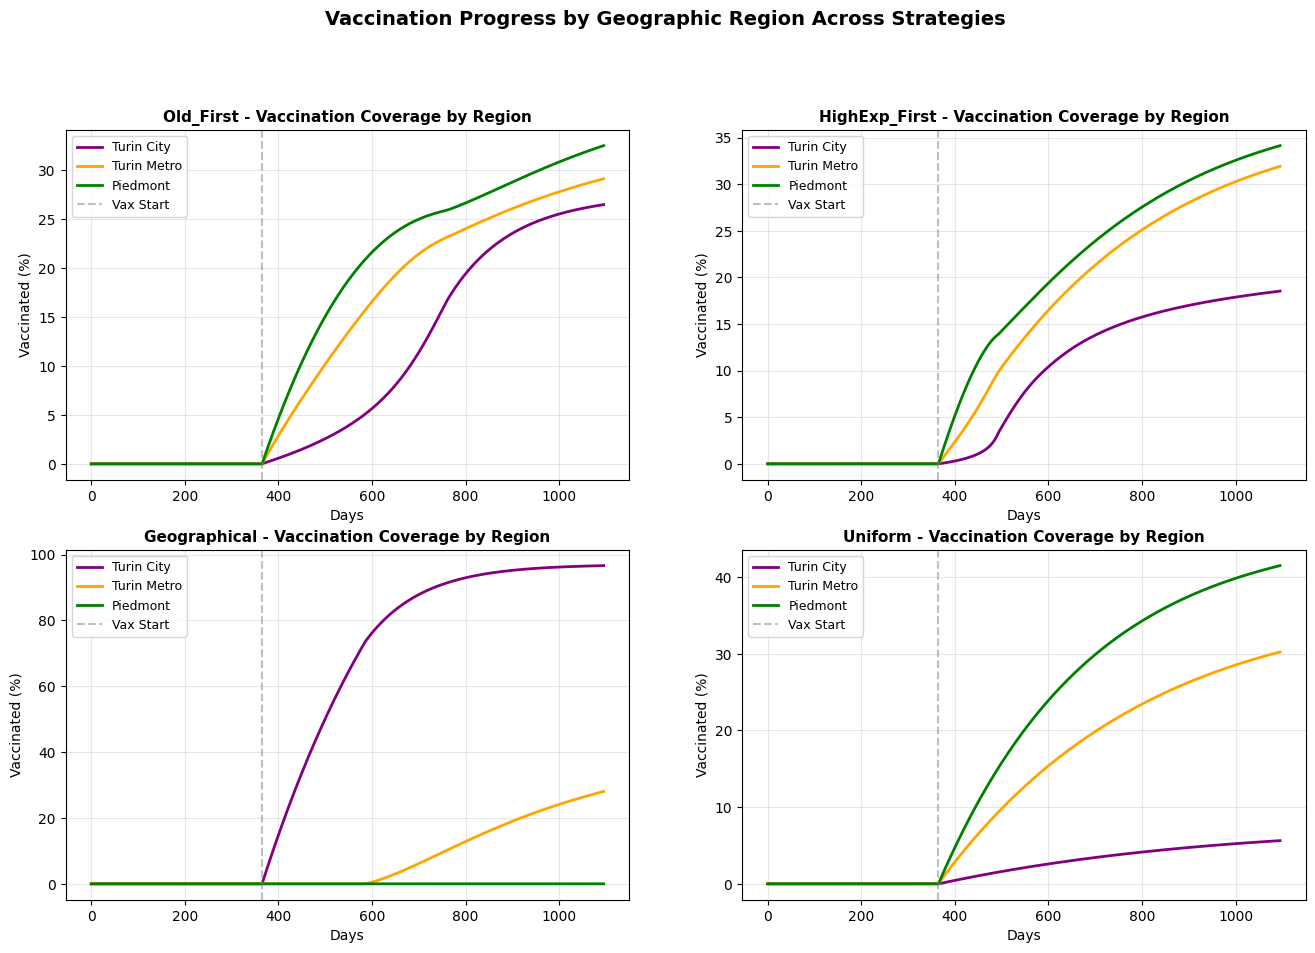

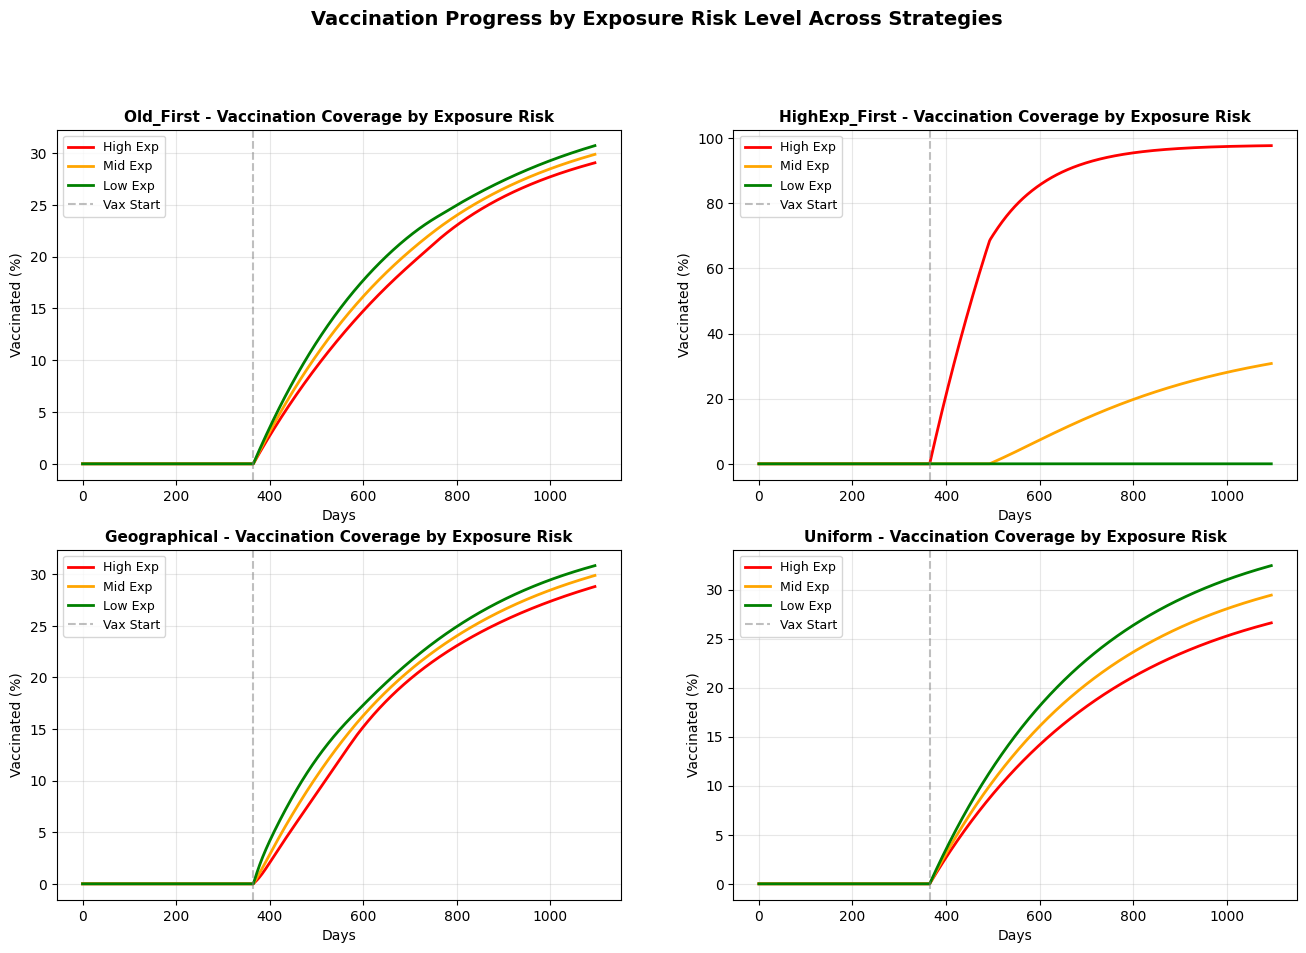

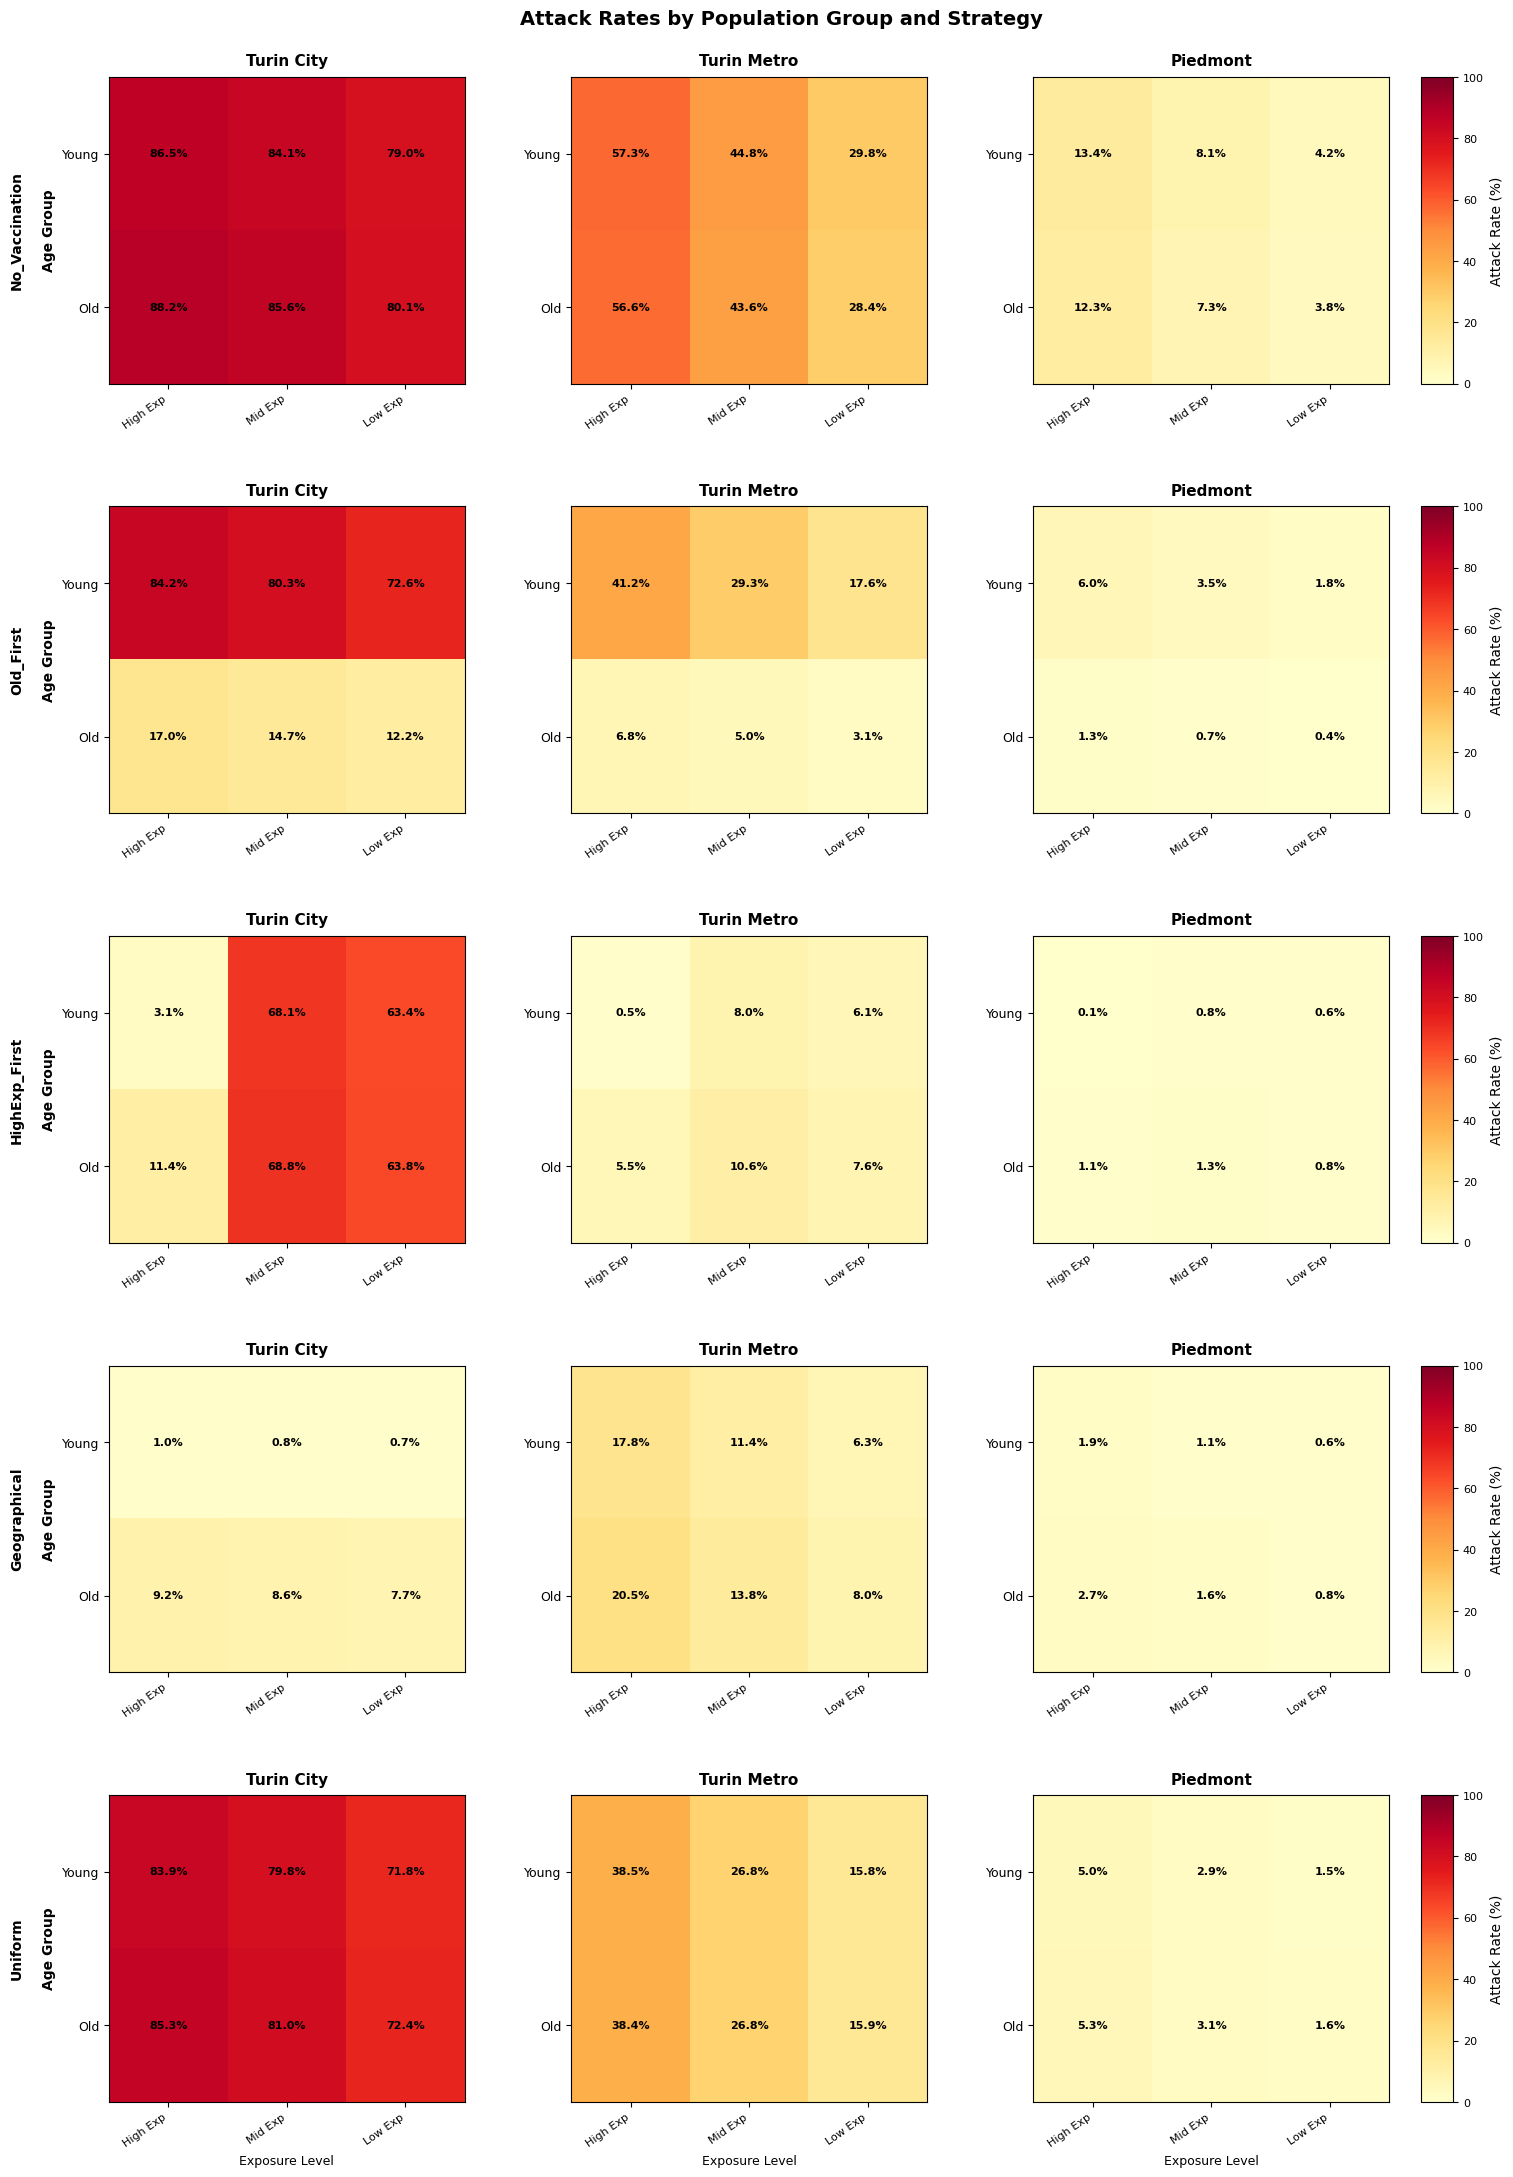

In [23]:
# ==========================================
# 7. DETAILED GROUP ANALYSIS ACROSS STRATEGIES
# ==========================================

def plot_age_comparison_by_strategy(t, res_dict):
    """Compare epidemic dynamics between age groups across all vaccination strategies"""
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    colors_young = {'No_Vaccination': '#1f77b4', 'Old_First': '#ff7f0e', 
                   'HighExp_First': '#2ca02c', 'Geographical': '#d62728', 'Uniform': '#9467bd'}
    colors_old = {k: v for k, v in colors_young.items()}  # Use same colors
    
    for strat, data in res_dict.items():
        results_reshaped = data.reshape((len(t), NUM_GROUPS, 7))
        
        # Calculate populations
        young_pop = 0
        old_pop = 0
        for g in range(3):
            for w in range(3):
                young_idx = get_group_features(g * 6 + 0 * 3 + w)
                old_idx = get_group_features(g * 6 + 1 * 3 + w)
                young_pop += results_reshaped[0, g * 6 + 0 * 3 + w, :5].sum()
                old_pop += results_reshaped[0, g * 6 + 1 * 3 + w, :5].sum()
        
        young_infections = []
        old_infections = []
        young_deaths = []
        old_deaths = []
        
        for time_idx in range(len(t)):
            young_i = 0
            young_d = 0
            old_i = 0
            old_d = 0
            
            for g in range(3):
                for w in range(3):
                    young_idx = g * 6 + 0 * 3 + w
                    old_idx = g * 6 + 1 * 3 + w
                    young_i += results_reshaped[time_idx, young_idx, 2]  # Symptomatic
                    young_d += results_reshaped[time_idx, young_idx, 5]  # Deaths
                    old_i += results_reshaped[time_idx, old_idx, 2]
                    old_d += results_reshaped[time_idx, old_idx, 5]
            
            young_infections.append(young_i)
            old_infections.append(old_i)
            young_deaths.append(young_d)
            old_deaths.append(old_d)
        
        # Convert to rates
        young_infection_rate = np.array(young_infections) / young_pop * 100
        old_infection_rate = np.array(old_infections) / old_pop * 100
        young_death_rate = np.array(young_deaths) / young_pop * 100
        old_death_rate = np.array(old_deaths) / old_pop * 100
        
        # Plot infections
        axes[0, 0].plot(t, young_infection_rate, label=strat, color=colors_young[strat], linewidth=2, alpha=0.8)
        axes[0, 1].plot(t, old_infection_rate, label=strat, color=colors_old[strat], linewidth=2, alpha=0.8)
        
        # Plot deaths
        axes[1, 0].plot(t, young_death_rate, label=strat, color=colors_young[strat], linewidth=2, alpha=0.8)
        axes[1, 1].plot(t, old_death_rate, label=strat, color=colors_old[strat], linewidth=2, alpha=0.8)
    
    # Format subplots
    axes[0, 0].set_title('Young - Symptomatic Infection Rate', fontsize=12, fontweight='bold')
    axes[0, 0].set_ylabel('Active Infections (% of pop)')
    axes[0, 0].axvline(x=VAX_START_DAY, linestyle='--', color='gray', alpha=0.5)
    axes[0, 0].legend(fontsize=8)
    axes[0, 0].grid(True, alpha=0.3)
    
    axes[0, 1].set_title('Old - Symptomatic Infection Rate', fontsize=12, fontweight='bold')
    axes[0, 1].set_ylabel('Active Infections (% of pop)')
    axes[0, 1].axvline(x=VAX_START_DAY, linestyle='--', color='gray', alpha=0.5)
    axes[0, 1].legend(fontsize=8)
    axes[0, 1].grid(True, alpha=0.3)
    
    axes[1, 0].set_title('Young - Cumulative Death Rate', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Days')
    axes[1, 0].set_ylabel('Deaths (% of pop)')
    axes[1, 0].axvline(x=VAX_START_DAY, linestyle='--', color='gray', alpha=0.5)
    axes[1, 0].legend(fontsize=8)
    axes[1, 0].grid(True, alpha=0.3)
    
    axes[1, 1].set_title('Old - Cumulative Death Rate', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Days')
    axes[1, 1].set_ylabel('Deaths (% of pop)')
    axes[1, 1].axvline(x=VAX_START_DAY, linestyle='--', color='gray', alpha=0.5)
    axes[1, 1].legend(fontsize=8)
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.suptitle('Age Group Comparison Across Vaccination Strategies', fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig('age_comparison_strategies.png', dpi=300, bbox_inches='tight')
    plt.show()


def plot_geographic_comparison_by_strategy(t, res_dict):
    """Compare epidemic dynamics across geographic regions for each vaccination strategy"""
    
    n_strategies = len(res_dict)
    # Use GridSpec for better layout control
    fig = plt.figure(figsize=(15, 4.5*n_strategies))
    gs = fig.add_gridspec(n_strategies, 2, hspace=0.35, wspace=0.25, 
                          left=0.08, right=0.95, top=0.94, bottom=0.06)
    
    colors = {'Turin_City': 'purple', 'Turin_Metro': 'orange', 'Piedmont': 'green'}
    
    for idx, (strat, data) in enumerate(res_dict.items()):
        results_reshaped = data.reshape((len(t), NUM_GROUPS, 7))
        
        # Calculate initial populations for each region
        geo_populations = []
        for g_idx in range(3):
            pop = 0
            for a in range(2):
                for w in range(3):
                    group_idx = g_idx * 6 + a * 3 + w
                    pop += results_reshaped[0, group_idx, :5].sum()
            geo_populations.append(pop)
        
        # Create subplots using GridSpec
        ax_infections = fig.add_subplot(gs[idx, 0])
        ax_deaths = fig.add_subplot(gs[idx, 1])
        
        for g_idx, geo in enumerate(GEOS):
            geo_infections = []
            geo_deaths = []
            
            for time_idx in range(len(t)):
                geo_i = 0
                geo_d = 0
                
                for a in range(2):
                    for w in range(3):
                        group_idx = g_idx * 6 + a * 3 + w
                        geo_i += results_reshaped[time_idx, group_idx, 2]  # Symptomatic
                        geo_d += results_reshaped[time_idx, group_idx, 5]  # Deaths
                
                geo_infections.append(geo_i)
                geo_deaths.append(geo_d)
            
            # Convert to rates
            infection_rate = np.array(geo_infections) / geo_populations[g_idx] * 100
            death_rate = np.array(geo_deaths) / geo_populations[g_idx] * 100
            
            ax_infections.plot(t, infection_rate, label=geo.replace('_', ' '), 
                            color=colors[geo], linewidth=2)
            ax_deaths.plot(t, death_rate, label=geo.replace('_', ' '), 
                            color=colors[geo], linewidth=2)
        
        ax_infections.axvline(x=VAX_START_DAY, linestyle='--', color='gray', alpha=0.5)
        ax_infections.set_title(f'{strat} - Symptomatic Infection Rate by Region', 
                               fontsize=11, fontweight='bold', pad=8)
        ax_infections.set_ylabel('Active Infections (% of pop)', fontsize=10)
        ax_infections.legend(fontsize=9, loc='best')
        ax_infections.grid(True, alpha=0.3)
        
        ax_deaths.axvline(x=VAX_START_DAY, linestyle='--', color='gray', alpha=0.5)
        ax_deaths.set_title(f'{strat} - Cumulative Death Rate by Region', 
                           fontsize=11, fontweight='bold', pad=8)
        ax_deaths.set_ylabel('Deaths (% of pop)', fontsize=10)
        ax_deaths.legend(fontsize=9, loc='best')
        ax_deaths.grid(True, alpha=0.3)
        
        if idx == n_strategies - 1:
            ax_infections.set_xlabel('Days', fontsize=10)
            ax_deaths.set_xlabel('Days', fontsize=10)
    
    plt.suptitle('Geographic Comparison Across Vaccination Strategies', 
                 fontsize=14, fontweight='bold', y=0.98)
    plt.savefig('geographic_comparison_strategies.png', dpi=300, bbox_inches='tight')
    plt.show()


def plot_exposure_comparison_by_strategy(t, res_dict):
    """Compare epidemic dynamics across work exposure levels for all vaccination strategies"""
    
    n_strategies = len(res_dict)
    # Use GridSpec for better layout control
    fig = plt.figure(figsize=(15, 4.5*n_strategies))
    gs = fig.add_gridspec(n_strategies, 2, hspace=0.35, wspace=0.25, 
                          left=0.08, right=0.95, top=0.94, bottom=0.06)
    
    colors = {'High_Exp': 'red', 'Mid_Exp': 'orange', 'Low_Exp': 'green'}
    
    for strat_idx, (strat, data) in enumerate(res_dict.items()):
        results_reshaped = data.reshape((len(t), NUM_GROUPS, 7))
        
        # Calculate initial populations for each exposure level
        work_populations = []
        for w_idx in range(3):
            pop = 0
            for g in range(3):
                for a in range(2):
                    group_idx = g * 6 + a * 3 + w_idx
                    pop += results_reshaped[0, group_idx, :5].sum()
            work_populations.append(pop)
        
        # Create subplots using GridSpec
        ax_infections = fig.add_subplot(gs[strat_idx, 0])
        ax_deaths = fig.add_subplot(gs[strat_idx, 1])
        
        for w_idx, work in enumerate(WORKS):
            work_infections = []
            work_deaths = []
            
            for time_idx in range(len(t)):
                work_i = 0
                work_d = 0
            
                for g in range(3):
                    for a in range(2):
                        group_idx = g * 6 + a * 3 + w_idx
                        work_i += results_reshaped[time_idx, group_idx, 2]  # Symptomatic
                        work_d += results_reshaped[time_idx, group_idx, 5]  # Deaths
                
                work_infections.append(work_i)
                work_deaths.append(work_d)
            
            # Convert to rates
            infection_rate = np.array(work_infections) / work_populations[w_idx] * 100
            death_rate = np.array(work_deaths) / work_populations[w_idx] * 100
            
            ax_infections.plot(t, infection_rate, label=work.replace('_', ' '), 
                              color=colors[work], linewidth=2)
            ax_deaths.plot(t, death_rate, label=work.replace('_', ' '), 
                          color=colors[work], linewidth=2)
        
        # Format subplots for this strategy
        ax_infections.axvline(x=VAX_START_DAY, linestyle='--', color='gray', alpha=0.5)
        ax_infections.set_title(f'{strat} - Symptomatic Infection Rate', 
                               fontsize=11, fontweight='bold', pad=8)
        ax_infections.set_ylabel('Active Infections (% of pop)', fontsize=10)
        ax_infections.legend(fontsize=9, loc='best')
        ax_infections.grid(True, alpha=0.3)
        
        ax_deaths.axvline(x=VAX_START_DAY, linestyle='--', color='gray', alpha=0.5)
        ax_deaths.set_title(f'{strat} - Cumulative Death Rate', 
                           fontsize=11, fontweight='bold', pad=8)
        ax_deaths.set_ylabel('Deaths (% of pop)', fontsize=10)
        ax_deaths.legend(fontsize=9, loc='best')
        ax_deaths.grid(True, alpha=0.3)
        
        # Add x-label only to bottom row
        if strat_idx == n_strategies - 1:
            ax_infections.set_xlabel('Days', fontsize=10)
            ax_deaths.set_xlabel('Days', fontsize=10)
    
    plt.suptitle('Exposure Level Comparison Across All Vaccination Strategies', 
                 fontsize=14, fontweight='bold', y=0.98)
    plt.savefig('exposure_comparison_strategies.png', dpi=300, bbox_inches='tight')
    plt.show()


def plot_vaccination_progress_by_group(t, res_dict):
    """Show vaccination progress across different population groups (by Age)"""
    
    # Only plot vaccination strategies (exclude No_Vaccination)
    vax_strategies = {k: v for k, v in res_dict.items() if k != 'No_Vaccination'}
    
    if len(vax_strategies) == 0:
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()
    
    colors_age = {'Young': 'blue', 'Old': 'red'}
        
    for strat_idx, (strat, data) in enumerate(list(vax_strategies.items())[:4]):
        results_reshaped = data.reshape((len(t), NUM_GROUPS, 7))
        
        # Get vaccinated by age group
        young_vax = []
        old_vax = []
        young_pop = 0
        old_pop = 0
        
        for g in range(3):
            for w in range(3):
                young_idx = g * 6 + 0 * 3 + w
                old_idx = g * 6 + 1 * 3 + w
                young_pop += results_reshaped[0, young_idx, 0]  # Initial susceptible
                old_pop += results_reshaped[0, old_idx, 0]
        
        for time_idx in range(len(t)):
            young_v = 0
            old_v = 0
            
            for g in range(3):
                for w in range(3):
                    young_idx = g * 6 + 0 * 3 + w
                    old_idx = g * 6 + 1 * 3 + w
                    young_v += results_reshaped[time_idx, young_idx, 6]  # Vaccinated
                    old_v += results_reshaped[time_idx, old_idx, 6]
            
            young_vax.append(young_v / young_pop * 100)
            old_vax.append(old_v / old_pop * 100)
        
        axes[strat_idx].plot(t, young_vax, label='Young', color=colors_age['Young'], linewidth=2)
        axes[strat_idx].plot(t, old_vax, label='Old', color=colors_age['Old'], linewidth=2)
        axes[strat_idx].axvline(x=VAX_START_DAY, linestyle='--', color='gray', alpha=0.5, label='Vax Start')
        axes[strat_idx].set_title(f'{strat} - Vaccination Coverage by Age', fontsize=11, fontweight='bold')
        axes[strat_idx].set_xlabel('Days')
        axes[strat_idx].set_ylabel('Vaccinated (%)')
        axes[strat_idx].legend(fontsize=9)
        axes[strat_idx].grid(True, alpha=0.3)
    
    # Hide unused subplots if fewer than 4 strategies
    for i in range(len(vax_strategies), 4):
        axes[i].axis('off')
    
    plt.suptitle('Vaccination Progress by Age Group Across Strategies', fontsize=14, fontweight='bold', y=1.00)
    plt.savefig('vaccination_progress_by_age.png', dpi=300, bbox_inches='tight')
    plt.show()


def plot_vaccination_progress_by_region(t, res_dict):
    """Show vaccination progress across different geographic regions"""
    
    # Only plot vaccination strategies (exclude No_Vaccination)
    vax_strategies = {k: v for k, v in res_dict.items() if k != 'No_Vaccination'}
    
    if len(vax_strategies) == 0:
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()
        
    colors_geo = {'Turin_City': 'purple', 'Turin_Metro': 'orange', 'Piedmont': 'green'}
    
    for strat_idx, (strat, data) in enumerate(list(vax_strategies.items())[:4]):
        results_reshaped = data.reshape((len(t), NUM_GROUPS, 7))
        
        # Get vaccinated by geographic region
        geo_vax = {geo: [] for geo in GEOS}
        geo_pop = {geo: 0 for geo in GEOS}
        
        # Calculate initial populations
        for g_idx in range(3):
            for a in range(2):
                for w in range(3):
                    group_idx = g_idx * 6 + a * 3 + w
                    geo_pop[GEOS[g_idx]] += results_reshaped[0, group_idx, 0]  # Initial susceptible
        
        # Calculate vaccination over time
        for time_idx in range(len(t)):
            for g_idx in range(3):
                geo_v = 0
                for a in range(2):
                    for w in range(3):
                        group_idx = g_idx * 6 + a * 3 + w
                        geo_v += results_reshaped[time_idx, group_idx, 6]  # Vaccinated
                geo_vax[GEOS[g_idx]].append(geo_v / geo_pop[GEOS[g_idx]] * 100)
        
        for geo in GEOS:
            axes[strat_idx].plot(t, geo_vax[geo], label=geo.replace('_', ' '), 
                               color=colors_geo[geo], linewidth=2)
        
        axes[strat_idx].axvline(x=VAX_START_DAY, linestyle='--', color='gray', alpha=0.5, label='Vax Start')
        axes[strat_idx].set_title(f'{strat} - Vaccination Coverage by Region', fontsize=11, fontweight='bold')
        axes[strat_idx].set_xlabel('Days')
        axes[strat_idx].set_ylabel('Vaccinated (%)')
        axes[strat_idx].legend(fontsize=9)
        axes[strat_idx].grid(True, alpha=0.3)
    
    # Hide unused subplots if fewer than 4 strategies
    for i in range(len(vax_strategies), 4):
        axes[i].axis('off')
    
    plt.suptitle('Vaccination Progress by Geographic Region Across Strategies', fontsize=14, fontweight='bold', y=1.00)
    plt.savefig('vaccination_progress_by_region.png', dpi=300, bbox_inches='tight')
    plt.show()


def plot_vaccination_progress_by_exposure(t, res_dict):
    """Show vaccination progress across different exposure risk levels"""
    
    # Only plot vaccination strategies (exclude No_Vaccination)
    vax_strategies = {k: v for k, v in res_dict.items() if k != 'No_Vaccination'}
    
    if len(vax_strategies) == 0:
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()
        
    colors_work = {'High_Exp': 'red', 'Mid_Exp': 'orange', 'Low_Exp': 'green'}
    
    for strat_idx, (strat, data) in enumerate(list(vax_strategies.items())[:4]):
        results_reshaped = data.reshape((len(t), NUM_GROUPS, 7))
        
        # Get vaccinated by exposure level
        work_vax = {work: [] for work in WORKS}
        work_pop = {work: 0 for work in WORKS}
        
        # Calculate initial populations
        for w_idx in range(3):
            for g in range(3):
                for a in range(2):
                    group_idx = g * 6 + a * 3 + w_idx
                    work_pop[WORKS[w_idx]] += results_reshaped[0, group_idx, 0]  # Initial susceptible
        
        # Calculate vaccination over time
        for time_idx in range(len(t)):
            for w_idx in range(3):
                work_v = 0
                for g in range(3):
                    for a in range(2):
                        group_idx = g * 6 + a * 3 + w_idx
                        work_v += results_reshaped[time_idx, group_idx, 6]  # Vaccinated
                work_vax[WORKS[w_idx]].append(work_v / work_pop[WORKS[w_idx]] * 100)
        
        for work in WORKS:
            axes[strat_idx].plot(t, work_vax[work], label=work.replace('_', ' '), 
                               color=colors_work[work], linewidth=2)
        
        axes[strat_idx].axvline(x=VAX_START_DAY, linestyle='--', color='gray', alpha=0.5, label='Vax Start')
        axes[strat_idx].set_title(f'{strat} - Vaccination Coverage by Exposure Risk', fontsize=11, fontweight='bold')
        axes[strat_idx].set_xlabel('Days')
        axes[strat_idx].set_ylabel('Vaccinated (%)')
        axes[strat_idx].legend(fontsize=9)
        axes[strat_idx].grid(True, alpha=0.3)
    
    # Hide unused subplots if fewer than 4 strategies
    for i in range(len(vax_strategies), 4):
        axes[i].axis('off')
    
    plt.suptitle('Vaccination Progress by Exposure Risk Level Across Strategies', fontsize=14, fontweight='bold', y=1.00)
    plt.savefig('vaccination_progress_by_exposure.png', dpi=300, bbox_inches='tight')
    plt.show()


def plot_attack_rate_heatmaps_by_strategy(res_dict):
    """Display attack rate heatmaps for each vaccination strategy"""
    
    n_strategies = len(res_dict)
    # Adjust figure size and spacing for better layout
    fig = plt.figure(figsize=(16, 4.5*n_strategies))
    gs = fig.add_gridspec(n_strategies, 3, hspace=0.4, wspace=0.3, 
                          left=0.08, right=0.88, top=0.95, bottom=0.05)
    
    for strat_idx, (strat, data) in enumerate(res_dict.items()):
        results_reshaped = data.reshape((-1, NUM_GROUPS, 7))
        
        # Calculate attack rate for each group
        attack_rates = np.zeros((len(GEOS), len(AGES), len(WORKS)))
        
        for g in range(len(GEOS)):
            for a in range(len(AGES)):
                for w in range(len(WORKS)):
                    group_idx = g * 6 + a * 3 + w
                    # Initial population
                    initial_pop = results_reshaped[0, group_idx, :].sum() - results_reshaped[0, group_idx, 5]
                    # Final recovered + dead
                    final_affected = results_reshaped[-1, group_idx, 4] + results_reshaped[-1, group_idx, 5]
                    attack_rates[g, a, w] = (final_affected / initial_pop) * 100
        axes_row = []
        for g_idx, geo in enumerate(GEOS):
            ax = fig.add_subplot(gs[strat_idx, g_idx])
            axes_row.append(ax)
            
            im = ax.imshow(attack_rates[g_idx, :, :], cmap='YlOrRd', aspect='auto', vmin=0, vmax=100)
            ax.set_title(f'{geo.replace("_", " ")}', fontsize=11, fontweight='bold', pad=8)
            
            if g_idx == 0:
                ax.set_ylabel(f'{strat}\n\nAge Group', fontsize=10, fontweight='bold')
            
            if strat_idx == n_strategies - 1:
                ax.set_xlabel('Exposure Level', fontsize=9)
            
            ax.set_xticks(range(len(WORKS)))
            ax.set_xticklabels([w.replace('_', ' ') for w in WORKS], rotation=35, ha='right', fontsize=8)
            ax.set_yticks(range(len(AGES)))
            ax.set_yticklabels(AGES, fontsize=9)
            
            # Add text annotations
            for i in range(len(AGES)):
                for j in range(len(WORKS)):
                    text = ax.text(j, i, f'{attack_rates[g_idx, i, j]:.1f}%',
                                 ha="center", va="center", color="black", fontsize=8, fontweight='bold')
        
        # Add colorbar for each row with proper positioning
        cbar_ax = fig.add_axes([0.90, gs[strat_idx, 0].get_position(fig).y0, 
                                0.02, gs[strat_idx, 0].get_position(fig).height])
        cbar = fig.colorbar(im, cax=cbar_ax, label='Attack Rate (%)')
        cbar.ax.tick_params(labelsize=8)
    
    plt.suptitle('Attack Rates by Population Group and Strategy', fontsize=14, fontweight='bold', y=0.98)
    plt.savefig('attack_rate_heatmaps.png', dpi=300, bbox_inches='tight')
    plt.show()


# Run all detailed analysis plots
if __name__ == "__main__":
    print("\n" + "="*70)
    print("DETAILED GROUP ANALYSIS")
    print("="*70)
    
    plot_age_comparison_by_strategy(t, res_dict)
    plot_geographic_comparison_by_strategy(t, res_dict)
    plot_exposure_comparison_by_strategy(t, res_dict)
    plot_vaccination_progress_by_group(t, res_dict)
    plot_vaccination_progress_by_region(t, res_dict)
    plot_vaccination_progress_by_exposure(t, res_dict)
    plot_attack_rate_heatmaps_by_strategy(res_dict)